Використай цей шаблон в роботі з датасетом. Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань. Обмежся функціями з наведених бібліотек.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Завантаж датасет з бібліотеки seaborn:

In [ ]:
titanic_df = sns.load_dataset("titanic")

Переглянь перші рядки датасету. Зроби висновок, чи коректно він завантажився.

In [ ]:
#переглядаємо перші рядки датасету
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
#перевіряємо тип даних, щоб переконатися, що у нас вийшов датафрейм
print(f"Тип даних для змінної нашого датасету: {type(titanic_df)}")
#перевіряємо розмір таблиці
print(f"Розмір таблиці: {titanic_df.shape}")

Тип даних для змінної нашого датасету: <class 'pandas.core.frame.DataFrame'>
Розмір таблиці: (891, 15)


Робимо висновок, що датасет завантажився коректно:
1. Ми бачимо перші рядки, вони не містять явних помилок, або пошкоджень.
2. Завантажений датасет має тип об'єкту Pandas.Dataframe
3. Розмір таблиці відповідає очікуванням

In [ ]:
#далі працюємо з копією датасету
titanic_df_copy = titanic_df.copy()

Перевір типи стовпців. Які з них потребують перетворення?

In [ ]:
print(f"Перевіряємо типи стовпців:\n{titanic_df_copy.dtypes}")

#Перетворюємо числові поля int64 на int8 для зменшення споживання пам'яті датафреймом, тому що їх значення не перевищує 127
titanic_df_copy['survived'] = titanic_df_copy['survived'].astype(np.int8) #приймає значення 0 чи 1
titanic_df_copy['pclass'] = titanic_df_copy['pclass'].astype(np.int8) #приймає значення 1, 2, 3
titanic_df_copy['sibsp'] = titanic_df_copy['sibsp'].astype(np.int8) #Кількість братів/сестер або чоловіків/дружин на борту (макс. значення = 8)
titanic_df_copy['parch'] = titanic_df_copy['parch'].astype(np.int8) #Кількість батьків або дітей на борту (макс. значення = 6)
#Маємо стовпці з обмеженою кількістю унікальних значень, для економії пам'яті перетворюємо тип на Category
titanic_df_copy['sex'] = titanic_df_copy['sex'].astype('category') #Стать пасажира (male, female)
titanic_df_copy['embarked'] = titanic_df_copy['embarked'].astype('category') #Порт посадки: C - Cherbourg, Q - Queenstown, S - Southampton
titanic_df_copy['who'] = titanic_df_copy['who'].astype('category') #Категорія пасажира за віком і статтю: man, woman, child
titanic_df_copy['embark_town'] = titanic_df_copy['embark_town'].astype('category') #Назва міста посадки (Cherbourg, Queenstown, Southampton)
titanic_df_copy['alive'] = titanic_df_copy['alive'].astype('category') #'yes' або 'no' - чи вижив пасажир

#Перевіряємо використання пам'яті до та після перетворень
print("="*50)
memory_before = titanic_df.memory_usage(deep=True).sum()
memory_after = titanic_df_copy.memory_usage(deep=True).sum()
print(f"Використання пам'яті до перетворення типів {memory_before} байт")
print(f"Використання пам'яті після перетворення типів {memory_after} байт")
print(f"Вивільнили пам'яті: {memory_before-memory_after} байт, використання пам'яті зменшено на {(memory_before-memory_after)/memory_before*100:.1f} %")

Перевіряємо типи стовпців:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
Використання пам'яті до перетворення типів 285564 байт
Використання пам'яті після перетворення типів 28130 байт
Вивільнили пам'яті: 257434 байт, використання пам'яті зменшено на 90.1 %


Висновок: в цілому значення у стовпцях відповідають типам даних, визначених при завантаженні датасету. Але задля оптимізації пам'яті, виконали перетворення:
*   цілочисельних типів у відповідності до діапазону значень (int64 - int8)
*   у стовпцях з обмеженою кількістю унікальних значень - object на category

Після перетворення типів використання пам'яті зменшилося на 90 %. Зменшення використання пам'яті збільшить швидкість відпрацювання коду.

Перевір статистику по УСІМ стовпцям датасету.

In [ ]:
print("Огляд структури:")
print("="*50)
titanic_df_copy.info()
print("="*50)
titanic_df_copy.describe(include='all')

Огляд структури:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int8    
 1   pclass       891 non-null    int8    
 2   sex          891 non-null    category
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int8    
 5   parch        891 non-null    int8    
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    category
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    category
 13  alive        891 non-null    category
 14  alone        891 non-null    bool    
dtypes: bool(2), category(7), float64(2), int8(4)
memory usage: 26.5 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Спробуй оцінити кількість дублікатів. Виміряй число рядків, позбудься дублікатів, оціни нову кількість рядків. Різницю виведи на екран, це і буде кількість рядків.

In [ ]:
#кількість рядків до видалення дублікатів
before = titanic_df_copy.shape[0]
#видаляємо дублікати
titanic_df_copy = titanic_df_copy.drop_duplicates()
#кількість рядків після видалення дублікатів
after = titanic_df_copy.shape[0]

print(f"Кількість дублікатів - {before-after}")

Кількість дублікатів - 107


Необхідно створити єдиний стовпчик, що вказує кількість родичів для кожного пасажира на борту, замість:
Кількість братів/сестер або чоловіків/дружин на борту
Кількість батьків або дітей на борту
Булева ознака: True, якщо пасажир подорожував один (без родичів на борту)
після створення нового стовпчика, дропни попередні. Вони вже не потрібні.

In [ ]:
#створюємо новий стовпець (кількість родичів) = Кількість братів/сестер або чоловіків/дружин + Кількість батьків або дітей
titanic_df_copy['relatives_count'] = titanic_df_copy['sibsp'] + titanic_df_copy['parch']
#створюємо стовпець з булевою ознакою True, якщо пасажир подорожував один
titanic_df_copy['is_alone'] = (titanic_df_copy['relatives_count'] == 0)
#дропаєм попередні стовпці (також дропаєм alone - він відповідає новостворенному стовпцю is_alone)
columns_to_drop = ['sibsp', 'parch', 'alone']
titanic_df_copy.drop(columns=columns_to_drop, axis=1, inplace=True)
#результат
titanic_df_copy.head(10)

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,relatives_count,is_alone
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,1,False
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,1,False
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,0,True
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,1,False
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,0,True
5,0,3,male,NaN,8.4583,Q,Third,man,True,NaN,Queenstown,no,0,True
6,0,1,male,54.0,51.8625,S,First,man,True,E,Southampton,no,0,True
7,0,3,male,2.0,21.0750,S,Third,child,False,NaN,Southampton,no,4,False
8,1,3,female,27.0,11.1333,S,Third,woman,False,NaN,Southampton,yes,2,False
9,1,2,female,14.0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,1,False


Перевір частоту випадків за значеннями в  новому стовпчику (кількість родичів) використовуючи візуалізацію:

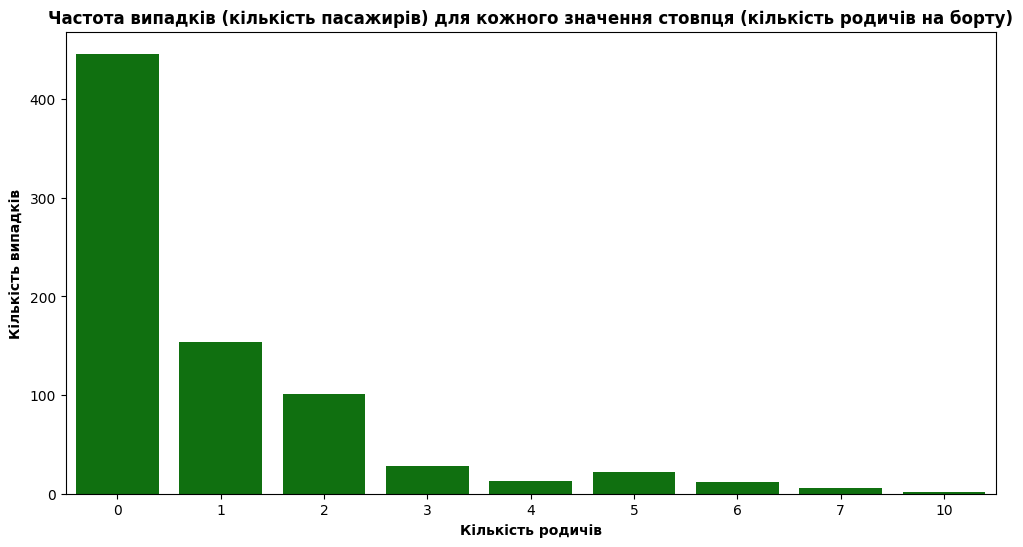

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=titanic_df_copy, x='relatives_count', color = 'g')
plt.title("Частота випадків (кількість пасажирів) для кожного значення стовпця (кількість родичів на борту)", fontweight = 'bold')
plt.xlabel("Кількість родичів", fontweight = 'bold')
plt.ylabel("Кількість випадків", fontweight = 'bold')
plt.show()

На графіку видно:
1. Більшість пасажирів подорожували самі (0 родичів)
2. Зменшення кількості пасажирів із зростанням кількості родичів
3. Пасажирів із великою кількістю родичів (>=4) дуже мало

Використовуючи лямбда функцію заміни кількість родичів, що перевищує число 5(три) на значення "above 5"(понад п'ять):

In [ ]:
titanic_df_copy['relatives_count_new'] = titanic_df_copy['relatives_count'].apply(
    lambda x: 'above 5' if x>5 else x)
#перевіряємо результат
mask = titanic_df_copy['relatives_count'] > 5
print(titanic_df_copy.loc[mask, ['relatives_count', 'relatives_count_new']])


     relatives_count relatives_count_new
13                 6             above 5
25                 6             above 5
59                 7             above 5
68                 6             above 5
71                 7             above 5
119                6             above 5
159               10             above 5
180               10             above 5
182                6             above 5
233                6             above 5
261                6             above 5
386                7             above 5
480                7             above 5
541                6             above 5
542                6             above 5
610                6             above 5
678                7             above 5
683                7             above 5
813                6             above 5
850                6             above 5


Необхідно вивести на екран статистику по модифікованому стовпцю, віднісши нову категорію в кінець( для цього слід перетворити стовпець в категорійний):

In [ ]:
#перетворюємо стовпець в категорійний
titanic_df_copy['relatives_count_new'] = titanic_df_copy['relatives_count_new'].astype('category')
#виводимо статистику стовпця
relatives_stat = titanic_df_copy['relatives_count_new'].value_counts(sort=False)
print(relatives_stat)

relatives_count_new
0          446
1          154
2          101
3           28
4           13
5           22
above 5     20
Name: count, dtype: int64


Заповни відсутні значення віку медіаною.

In [ ]:
#обчислюємо медіану
median_age = titanic_df_copy['age'].median()
print(f"Розрахована медіана віку: {median_age}")
#фіксуємо кількість пропусків до заповнення
before = titanic_df_copy['age'].isnull().sum()
print(f"Кількість пропусків перед заповненням: {before}")
#заповнюємо пропуски медіаною
titanic_df_copy['age'].fillna(median_age, inplace=True)
#кількість пропусків після заповнення
after = titanic_df_copy['age'].isnull().sum()
print(f"Кількість пропусків після заповнення: {after}")

Розрахована медіана віку: 28.25
Кількість пропусків перед заповненням: 106
Кількість пропусків після заповнення: 0


/tmp/ipython-input-1276941298.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df_copy['age'].fillna(median_age, inplace=True)


Створи новий стовпець, де вік представлено категорією, замість числа (наприклад: до 14 років, 14-34 роки, 35-59 років, 60 і більше років). Виконай задачу з використанням користувацької функції. Осіб з невідомим віком познач відповідно.

In [ ]:
#створюємо функцію для ранжування віку за запропонованими категоріями
def categorize_age(age):
  if age < 14:
    age_cat = 'below 14'
  elif age >= 14 and age < 35:
    age_cat = '14-34'
  elif age >= 35 and age < 60:
    age_cat = '35-59'
  elif age >= 60:
    age_cat = 'above 60'
  else:
    age_cat = 'unknown'
  return age_cat
#заповнюємо новий стовпець із використанням функції
titanic_df_copy['age_category'] = titanic_df_copy['age'].apply(categorize_age)
titanic_df_copy['age_category'] = titanic_df_copy['age_category'].astype('category')
#результат
titanic_df_copy.head(10)

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,relatives_count,is_alone,relatives_count_new,age_category
0,0,3,male,22.00,7.2500,S,Third,man,True,NaN,Southampton,no,1,False,1,14-34
1,1,1,female,38.00,71.2833,C,First,woman,False,C,Cherbourg,yes,1,False,1,35-59
2,1,3,female,26.00,7.9250,S,Third,woman,False,NaN,Southampton,yes,0,True,0,14-34
3,1,1,female,35.00,53.1000,S,First,woman,False,C,Southampton,yes,1,False,1,35-59
4,0,3,male,35.00,8.0500,S,Third,man,True,NaN,Southampton,no,0,True,0,35-59
5,0,3,male,28.25,8.4583,Q,Third,man,True,NaN,Queenstown,no,0,True,0,14-34
6,0,1,male,54.00,51.8625,S,First,man,True,E,Southampton,no,0,True,0,35-59
7,0,3,male,2.00,21.0750,S,Third,child,False,NaN,Southampton,no,4,False,4,below 14
8,1,3,female,27.00,11.1333,S,Third,woman,False,NaN,Southampton,yes,2,False,2,14-34
9,1,2,female,14.00,30.0708,C,Second,child,False,NaN,Cherbourg,yes,1,False,1,14-34


Перевір, в якій віковій категорії була найвища смертність. Для цього рекомендується перетворити стовпець 'alive' в булевий тип. Потім підрахувати загальну кількість пасажирів та кількість тих, хто не вижив. Потім обчисли відносний показниках для кожної категорії.

In [ ]:
conversion_map = {'yes': True, 'no': False}
titanic_df_copy['alive'] = titanic_df_copy['alive'].map(conversion_map)
titanic_df_copy['alive'] = titanic_df_copy['alive'].astype(bool)

#створення стовпця deceased_indicator (де 1 = не вижив)
#логічне заперечення (~alive) перетворює True/False на 1/0 відповідно
titanic_df_copy['deceased_indicator'] = ~titanic_df_copy['alive']

#групування та агрегація
mortality_analysis = titanic_df_copy.groupby('age_category').agg(
    total_passengers=('alive', 'count'), # Загальна кількість
    deceased=('deceased_indicator', 'sum')   # Сума (кількість) не виживших (де ~alive=1)
).reset_index()

#обчислення відносного показника смертності (Mortality Rate)
mortality_analysis['mortality_rate'] = (
    mortality_analysis['deceased'] / mortality_analysis['total_passengers']
)

#форматування та сортування результату
mortality_analysis['mortality_rate_percent'] = (
    mortality_analysis['mortality_rate'] * 100
).round(2).astype(str) + '%'

mortality_analysis.sort_values(by='mortality_rate', ascending=False, inplace=True)

print("Аналіз смертності за віковими категоріями")
print("-"*60)
print(mortality_analysis[['age_category', 'total_passengers', 'deceased', 'mortality_rate_percent']])

Аналіз смертності за віковими категоріями
------------------------------------------------------------
  age_category  total_passengers  deceased mortality_rate_percent
2     above 60                26        19                 73.08%
0        14-34               483       294                 60.87%
1        35-59               205       119                 58.05%
3     below 14                70        29                 41.43%


/tmp/ipython-input-2043528561.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortality_analysis = titanic_df_copy.groupby('age_category').agg(


Висновок:
Категорією з найвищою смертністю є "above 60" (понад 60 років) з показником 73% (19 із 26 пасажирів).

Діти ("below 14") мали нижчу смертність завдяки пріоритету евакуації ("Жінки та діти першими").

Люди похилого віку ("above 60") мали найнижчі шанси на виживання через фізичні обмеження та умови евакуації.

Відтвори cтатистику  смертності у вигляді кругової діаграми з розбивкою по віковим групам. Ти помітив, що відсотки відрізняються? Поясни чому.

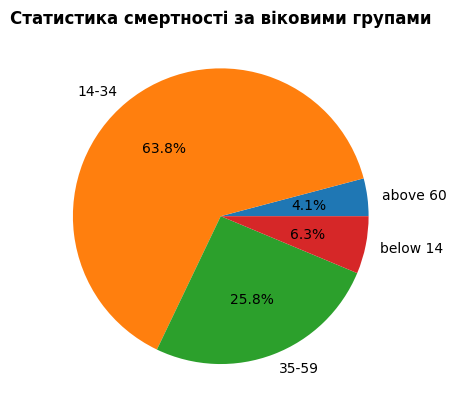

In [ ]:
plt.pie(mortality_analysis['deceased'],
        labels = mortality_analysis['age_category'],
        autopct='%1.1f%%')
plt.title("Статистика смертності за віковими групами", fontweight = 'bold')
plt.show()

Відсотки відрізняються, тому що на діаграмі візуалізована частка смертей по віковим групам від загальної кількості загиблих (хто склав більшість серед загиблих).
У минулому завданні ми вираховували частку смертей від кількості пасажирів у кожній віковій категорії (хто мав найгірші шанси на виживання).

*Бонусне завдання*
Підготуй розгорнуту статистику смертності по категорії віку, класу квитка, рівню каюти та кількості родичів. Які фактори, на твою думку, найбільше пов'язані з рівнем смерності? (наприклад: найбільша смертність у відсотковому значенні спостерігається серед вікової групи ... класу квитка.... при наявності ... родичів та для рівня каюти.... Фактор ... має найвищий вплив на смертність)

Аналіз смертності за классом квитка
------------------------------------------------------------
   pclass  total_passangers  deceased  mortality_rate_percent
2       3               405       301                   74.32
1       2               165        81                   49.09
0       1               214        79                   36.92


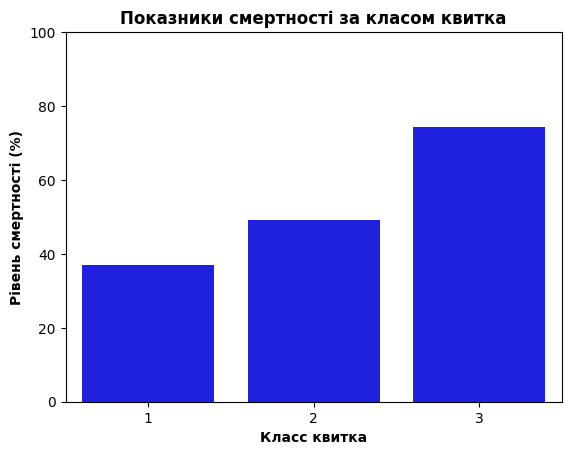

In [ ]:
#статистика смертності за класом квитка
pclass_mortality = titanic_df_copy.groupby('pclass').agg(
    total_passangers = ('alive', 'count'),
    deceased=('deceased_indicator', 'sum')
).reset_index()

pclass_mortality['mortality_rate'] = (pclass_mortality['deceased']/pclass_mortality['total_passangers'])
pclass_mortality['mortality_rate_percent'] = (pclass_mortality['mortality_rate'] * 100).round(2)
pclass_mortality.sort_values(by='mortality_rate', ascending=False, inplace=True)
print("Аналіз смертності за классом квитка")
print("-"*60)
print(pclass_mortality[['pclass', 'total_passangers', 'deceased', 'mortality_rate_percent']])
#візуалізуємо результати
sns.barplot(x = 'pclass',
            y = 'mortality_rate_percent',
            data = pclass_mortality,
            color = 'b')
plt.title("Показники смертності за класом квитка", fontweight = 'bold')
plt.xlabel("Класс квитка", fontweight = 'bold')
plt.ylabel("Рівень смертності (%)", fontweight = 'bold')
plt.ylim(0, 100)
plt.show()

Найвища смертність була у пасажирів 3-го класу, найменша смертність спостерігається у пасажирів 1-го класу. Це пов'язано із пріоритетом у евакуації та розташуванням кают (каюти 3-го класу були розташовані на нижніх палубах)

Аналіз смертності за рівнем палуби каюти
------------------------------------------------------------
      deck  total_passengers  deceased  mortality_rate_percent
7  Unknown               582       394                   67.70
0        A                15         8                   53.33
6        G                 4         2                   50.00
2        C                59        24                   40.68
5        F                13         5                   38.46
1        B                46        12                   26.09
4        E                32         8                   25.00
3        D                33         8                   24.24


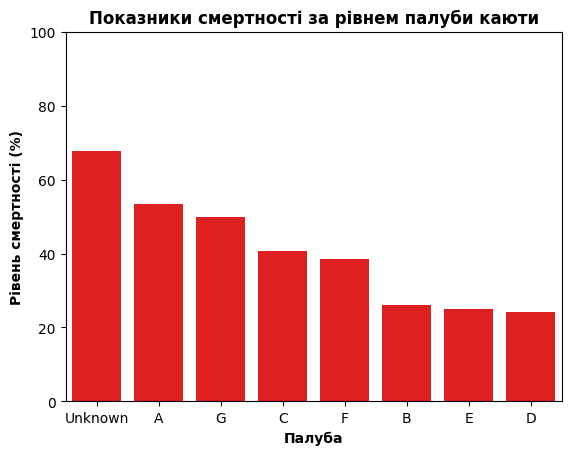

In [ ]:
#статистика смертності за рівнем палуби каюти
#заповнимо пропуски у стовпці, щоб дані відображались у статистиці
titanic_df_copy['deck'] = titanic_df_copy['deck'].astype(object).fillna('Unknown')

deck_mortality = titanic_df_copy.groupby('deck').agg(
    total_passengers = ('alive', 'count'),
    deceased = ('deceased_indicator', 'sum')
).reset_index()

deck_mortality['mortality_rate'] = (deck_mortality['deceased']/deck_mortality['total_passengers'])
deck_mortality['mortality_rate_percent'] = (deck_mortality['mortality_rate'] * 100).round(2)
deck_mortality.sort_values(by='mortality_rate', ascending=False, inplace=True)
print("Аналіз смертності за рівнем палуби каюти")
print("-"*60)
print(deck_mortality[['deck', 'total_passengers', 'deceased', 'mortality_rate_percent']])
#візуалізуємо результати
sns.barplot(x = 'deck',
            y = 'mortality_rate_percent',
            data = deck_mortality,
            color = 'r')
plt.title("Показники смертності за рівнем палуби каюти", fontweight = 'bold')
plt.xlabel("Палуба", fontweight = 'bold')
plt.ylabel("Рівень смертності (%)", fontweight = 'bold')
plt.ylim(0, 100)
plt.show()

Категорія Unknown (невідома палуба) має найбільшу кількість пасажирів і високий показник смертності (~67.7%), оскільки більшість пасажирів 3-го класу, у яких часто не було зареєстровано каюту, подорожували там. Палуби B, C, D, E, F мали найкращі шанси на виживання.

Аналіз смертності за классом квитка
------------------------------------------------------------
  relatives_count_new  total_passangers  deceased  mortality_rate_percent
5                   5                22        19                   86.36
6             above 5                20        16                   80.00
4                   4                13        10                   76.92
0                   0               446       296                   66.37
1                   1               154        69                   44.81
2                   2               101        43                   42.57
3                   3                28         8                   28.57


/tmp/ipython-input-1798779715.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relatives_mortality = titanic_df_copy.groupby('relatives_count_new').agg(


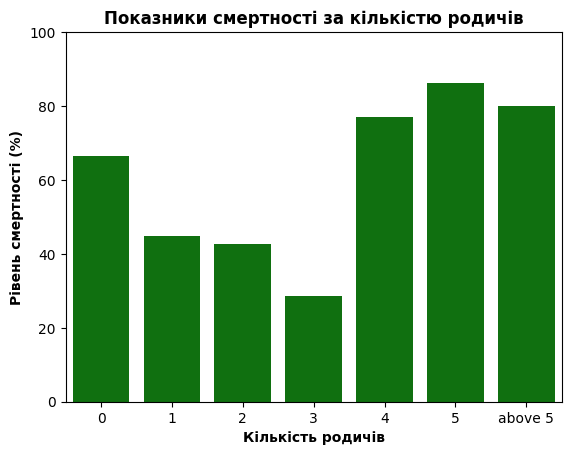

In [ ]:
#статистика смертності за кількістю родичів
relatives_mortality = titanic_df_copy.groupby('relatives_count_new').agg(
    total_passangers = ('alive', 'count'),
    deceased=('deceased_indicator', 'sum')
).reset_index()

relatives_mortality['mortality_rate'] = (relatives_mortality['deceased']/relatives_mortality['total_passangers'])
relatives_mortality['mortality_rate_percent'] = (relatives_mortality['mortality_rate'] * 100).round(2)
relatives_mortality.sort_values(by='mortality_rate', ascending=False, inplace=True)
print("Аналіз смертності за классом квитка")
print("-"*60)
print(relatives_mortality[['relatives_count_new', 'total_passangers', 'deceased', 'mortality_rate_percent']])
#візуалізуємо результати
sns.barplot(x = 'relatives_count_new',
            y = 'mortality_rate_percent',
            data = relatives_mortality,
            color = 'g')
plt.title("Показники смертності за кількістю родичів", fontweight = 'bold')
plt.xlabel("Кількість родичів", fontweight = 'bold')
plt.ylabel("Рівень смертності (%)", fontweight = 'bold')
plt.ylim(0, 100)
plt.show()

Висновок: Виживання є найвищим для пасажирів з 1, 2 або 3 родичами. Пасажири, які подорожували на самоті (0 родичів), мали значно гірші шанси на виживання, ніж ті, хто мав невелику родину. Найвищий ризик був у тих, хто подорожував з дуже великою кількістю родичів (above 5) — ймовірно, це великі родини 3-го класу, яким було складніше організовано евакуюватися.

Загальний підсумок:
Найбільша смертність у відсотковому значенні спостерігається:
1. Cеред вікової групи "above 60" (Люди похилого віку мали найнижчі шанси на виживання через фізичні обмеження та умови евакуації)
2. Класу квитка 3 (Це пов'язано із пріоритетом у евакуації та розташуванням кают (каюти 3-го класу були розташовані на нижніх палубах)
3. При наявності 5 і більше родичів (ймовірно, це великі родини, яким було складніше організовано евакуюватися)
4. Для рівня каюти Unknown (невідома палуба). Має найбільшу кількість пасажирів і високий показник смертності (~67.7%), оскільки більшість пасажирів 3-го класу, у яких часто не було зареєстровано каюту, подорожували там.

Фактор "пассажир 3-го классу із великою родиною" має найвищий вплив на смертність